In [97]:
import numpy as np

In [99]:
import pandas as pd

In [101]:
# Set seed for reproducibility
np.random.seed(seed=1234)

In [103]:
# Read from CSV to Pandas DataFrame
url = "https://raw.githubusercontent.com/rolandmueller/titanic/main/titanic3.csv"
df=pd.read_csv(url)

In [104]:
df.head(5)

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


# Exploratory data analysis (EDA)

Now that we loaded our data, we're ready to start exploring it to find interesting information.

In [109]:
import matplotlib.pyplot as plt

In [111]:
# Describe features
df.describe()

,pclass,survived,age,sibsp,parch,fare,body
count,1309.000000,1309.000000,1046.000000,1309.000000,1309.000000,1308.000000,121.000000
mean,2.294882,0.381971,29.881135,0.498854,0.385027,33.295479,160.809917
std,0.837836,0.486055,14.413500,1.041658,0.865560,51.758668,97.696922
min,1.000000,0.000000,0.166700,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,21.000000,0.000000,0.000000,7.895800,72.000000
50%,3.000000,0.000000,28.000000,0.000000,0.000000,14.454200,155.000000
75%,3.000000,1.000000,39.000000,1.000000,0.000000,31.275000,256.000000
max,3.000000,1.000000,80.000000,8.000000,9.000000,512.329200,328.000000


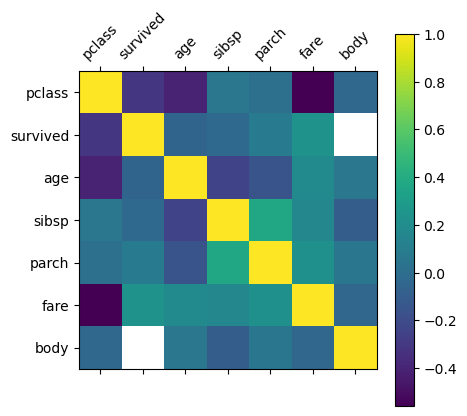

In [113]:
corr_matrix =df.corr(numeric_only=True)
plt.matshow(corr_matrix)
continuous_features = corr_matrix.columns
# plt.xticks(range(len(continuous_features)), continuous_features, rotation="45")
# plt.yticks(range(len(continuous_features)), continuous_features, rotation="45")
# plt.colorbar()
# plt.show()
plt.xticks(range(len(continuous_features)), continuous_features, rotation=45)
plt.yticks(range(len(continuous_features)), continuous_features)
plt.colorbar()
plt.show()

<Axes: >

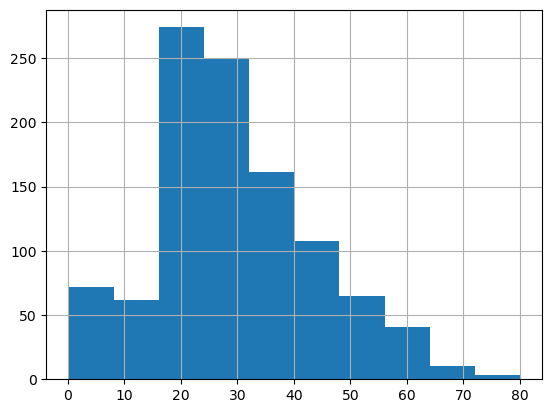

In [115]:
# Histograms
df["age"].hist()

In [117]:
# Unique values
df["embarked"].unique()

array(['S', 'C', nan, 'Q'], dtype=object)

In [119]:
# Selecting data by feature
df["name"].head()

0                      Allen, Miss. Elisabeth Walton
1                     Allison, Master. Hudson Trevor
2                       Allison, Miss. Helen Loraine
3               Allison, Mr. Hudson Joshua Creighton
4    Allison, Mrs. Hudson J C (Bessie Waldo Daniels)
Name: name, dtype: object

# Filtering

In [122]:
# Filtering
df[df["sex"]=="female"].head() 

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
6,1,1,"Andrews, Miss. Kornelia Theodosia",female,63.0,1,0,13502,77.9583,D7,S,10,NaN,"Hudson, NY"
8,1,1,"Appleton, Mrs. Edward Dale (Charlotte Lamson)",female,53.0,2,0,11769,51.4792,C101,S,D,NaN,"Bayside, Queens, NY"


# Sorting

In [125]:
df.sort_values("age", ascending=False).head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
14,1,1,"Barkworth, Mr. Algernon Henry Wilson",male,80.0,0,0,27042,30.0000,A23,S,B,NaN,"Hessle, Yorks"
61,1,1,"Cavendish, Mrs. Tyrell William (Julia Florence...",female,76.0,1,0,19877,78.8500,C46,S,6,NaN,"Little Onn Hall, Staffs"
1235,3,0,"Svensson, Mr. Johan",male,74.0,0,0,347060,7.7750,NaN,S,NaN,NaN,NaN
135,1,0,"Goldschmidt, Mr. George B",male,71.0,0,0,PC 17754,34.6542,A5,C,NaN,NaN,"New York, NY"
9,1,0,"Artagaveytia, Mr. Ramon",male,71.0,0,0,PC 17609,49.5042,NaN,C,NaN,22.0,"Montevideo, Uruguay"


# Grouping

In [128]:
# Grouping
survived_group = df.groupby("survived")
survived_group.mean(numeric_only=True)

,pclass,age,sibsp,parch,fare,body
survived,,,,,,
0,2.500618,30.545369,0.521632,0.328801,23.353831,160.809917
1,1.962000,28.918228,0.462000,0.476000,49.361184,NaN


# Indexing

In [131]:
# Selecting row 0
df.iloc[0, :]

pclass                                   1
survived                                 1
name         Allen, Miss. Elisabeth Walton
sex                                 female
age                                   29.0
sibsp                                    0
parch                                    0
ticket                               24160
fare                              211.3375
cabin                                   B5
embarked                                 S
boat                                     2
body                                   NaN
home.dest                     St Louis, MO
Name: 0, dtype: object

In [133]:
# Selecting a specific value
df.iloc[0, 1]

1

# Preprocessing

In [136]:
# Rows with at least one NaN value
df[pd.isnull(df).any(axis=1)].head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


In [138]:
# Drop rows with Nan values
df = df.dropna(subset=['age', 'embarked']) # removes rows with any NaN values
df = df.reset_index(drop=True) # reset's row indexes in case any rows were dropped
df.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


In [140]:
# Dropping multiple columns
df = df.drop(["name", "cabin", "ticket"], axis=1) # we won't use text features for our initial basic models
df.head()

,pclass,survived,sex,age,sibsp,parch,fare,embarked,boat,body,home.dest
0,1,1,female,29.0000,0,0,211.3375,S,2,NaN,"St Louis, MO"
1,1,1,male,0.9167,1,2,151.5500,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,female,2.0000,1,2,151.5500,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,male,30.0000,1,2,151.5500,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,female,25.0000,1,2,151.5500,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


In [142]:
# Map feature values
df["sex"] = df["sex"].map( {"female": 0, "male": 1} ).astype(int)
df["embarked"] = df["embarked"].dropna().map( {"S":0, "C":1, "Q":2} ).astype(int)
df.head()

,pclass,survived,sex,age,sibsp,parch,fare,embarked,boat,body,home.dest
0,1,1,0,29.0000,0,0,211.3375,0,2,NaN,"St Louis, MO"
1,1,1,1,0.9167,1,2,151.5500,0,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,0,2.0000,1,2,151.5500,0,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,1,30.0000,1,2,151.5500,0,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,0,25.0000,1,2,151.5500,0,NaN,NaN,"Montreal, PQ / Chesterville, ON"


# Feature engineering

In [145]:
# Lambda expressions to create new features
def get_family_size(sibsp, parch):
    family_size = sibsp + parch
    return family_size

In [147]:
df["family_size"] = df[["sibsp", "parch"]].apply(lambda x: get_family_size(x["sibsp"], x["parch"]), axis=1)
df.head()

,pclass,survived,sex,age,sibsp,parch,fare,embarked,boat,body,home.dest,family_size
0,1,1,0,29.0000,0,0,211.3375,0,2,NaN,"St Louis, MO",0
1,1,1,1,0.9167,1,2,151.5500,0,11,NaN,"Montreal, PQ / Chesterville, ON",3
2,1,0,0,2.0000,1,2,151.5500,0,NaN,NaN,"Montreal, PQ / Chesterville, ON",3
3,1,0,1,30.0000,1,2,151.5500,0,NaN,135.0,"Montreal, PQ / Chesterville, ON",3
4,1,0,0,25.0000,1,2,151.5500,0,NaN,NaN,"Montreal, PQ / Chesterville, ON",3


In [151]:
# Reorganize headers
df = df[["pclass", "sex", "age", "sibsp", "parch", "family_size", "fare", "embarked", "survived"]]
df.head()

,pclass,sex,age,sibsp,parch,family_size,fare,embarked,survived
0,1,0,29.0000,0,0,0,211.3375,0,1
1,1,1,0.9167,1,2,3,151.5500,0,1
2,1,0,2.0000,1,2,3,151.5500,0,0
3,1,1,30.0000,1,2,3,151.5500,0,0
4,1,0,25.0000,1,2,3,151.5500,0,0


# Save data

In [154]:
# Saving dataframe to CSV
df.to_csv("processed_titanic.csv", index=False)

In [158]:
# See the saved file
!dir

 Volume in drive C is Windows
 Volume Serial Number is EA6F-738A

 Directory of C:\Users\manda\MACHINE LEARNING\Machine-Learning

19-04-2026  22:54    <DIR>          .
18-04-2026  17:49    <DIR>          ..
19-04-2026  08:03    <DIR>          .ipynb_checkpoints
18-04-2026  18:23                94 DAY1.py
18-04-2026  21:22            21,707 NUMPY.ipynb
18-04-2026  18:21             1,217 NUMPY.py
19-04-2026  22:54           107,780 PANDAS.ipynb
19-04-2026  22:53            27,305 processed_titanic.csv
               5 File(s)        158,103 bytes
               3 Dir(s)  247,357,018,112 bytes free
